In [ ]:
!pip install pyspark==4.0.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = '/content/drive/MyDrive/flight_pipeline'

# Input (raw)
RAW_KAGGLE  = f'{BASE}/raw/kaggle/Clean_Dataset.csv'
RAW_DELAY   = f'{BASE}/raw/delay'

# Output layers
BRONZE  = f'{BASE}/bronze'
SILVER  = f'{BASE}/silver'
GOLD    = f'{BASE}/gold'
CURATED = f'{BASE}/curated'

import os
for path in [BRONZE, SILVER, GOLD, CURATED]:
    os.makedirs(path, exist_ok=True)

print("All folders ready.")

All folders ready.


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FlightPricePipeline") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.0


In [ ]:
# Read raw CSV
df_price_raw = spark.read.csv(RAW_KAGGLE, header=True, inferSchema=True)

print("Flight price raw shape:", df_price_raw.count(), "rows x", len(df_price_raw.columns), "cols")
df_price_raw.printSchema()
df_price_raw.show(3)

# Save to Bronze as Parquet (unmodified)
df_price_raw.write.mode("overwrite").parquet(f"{BRONZE}/flight_price")
print("Bronze - flight price saved.")

Flight price raw shape: 300153 rows x 12 cols
root
 |-- _c0: integer (nullable = true)
 |-- airline: string (nullable = true)
 |-- flight: string (nullable = true)
 |-- source_city: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stops: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- destination_city: string (nullable = true)
 |-- class: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- days_left: integer (nullable = true)
 |-- price: integer (nullable = true)

+---+--------+-------+-----------+--------------+-----+-------------+----------------+-------+--------+---------+-----+
|_c0| airline| flight|source_city|departure_time|stops| arrival_time|destination_city|  class|duration|days_left|price|
+---+--------+-------+-----------+--------------+-----+-------------+----------------+-------+--------+---------+-----+
|  0|SpiceJet|SG-8709|      Delhi|       Evening| zero|        Night|          Mumbai|Economy|    2.

In [ ]:
# Check the delay file loaded correctly
df_delay_raw = spark.read.csv(
    f"{RAW_DELAY}/Combined_Flights_2022.csv",
    header=True,
    inferSchema=True
)

print("Delay raw shape:", df_delay_raw.count(), "rows x", len(df_delay_raw.columns), "cols")
df_delay_raw.printSchema()
df_delay_raw.show(3)

# Save to Bronze unmodified
df_delay_raw.write.mode("overwrite").parquet(f"{BRONZE}/flight_delay")
print("Bronze - flight delay saved.")

Delay raw shape: 4078318 rows x 61 cols
root
 |-- FlightDate: string (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: boolean (nullable = true)
 |-- Diverted: boolean (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- DepDelayMinutes: double (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- ArrDelayMinutes: double (nullable = true)
 |-- AirTime: double (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- ActualElapsedTime: double (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_S

In [ ]:
import requests
import pandas as pd

CITY_COORDS = {
    "Delhi":     {"lat": 28.6139, "lon": 77.2090},
    "Mumbai":    {"lat": 19.0760, "lon": 72.8777},
    "Bangalore": {"lat": 12.9716, "lon": 77.5946},
    "Kolkata":   {"lat": 22.5726, "lon": 88.3639},
    "Hyderabad": {"lat": 17.3850, "lon": 78.4867},
    "Chennai":   {"lat": 13.0827, "lon": 80.2707},
}

START_DATE = "2022-02-11"
END_DATE   = "2022-03-31"

weather_records = []

for city, coords in CITY_COORDS.items():
    print(f"Fetching weather for {city}...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   coords["lat"],
        "longitude":  coords["lon"],
        "start_date": START_DATE,
        "end_date":   END_DATE,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",
        "timezone": "Asia/Kolkata"
    }
    response = requests.get(url, params=params)
    data = response.json()

    if "daily" not in data:
        print(f"  Warning: no data for {city}")
        continue

    daily = data["daily"]
    for i, date_str in enumerate(daily["time"]):
        weather_records.append({
            "city":             city,
            "date":             date_str,
            "temp_max_c":       daily["temperature_2m_max"][i],
            "temp_min_c":       daily["temperature_2m_min"][i],
            "precipitation_mm": daily["precipitation_sum"][i],
            "wind_speed_kmh":   daily["wind_speed_10m_max"][i],
        })

df_weather_pd = pd.DataFrame(weather_records)
print(f"\nTotal weather records: {len(df_weather_pd)}")

df_weather_raw = spark.createDataFrame(df_weather_pd)
df_weather_raw.write.mode("overwrite").parquet(f"{BRONZE}/weather")
print("Bronze - weather saved.")

Fetching weather for Delhi...
Fetching weather for Mumbai...
Fetching weather for Bangalore...
Fetching weather for Kolkata...
Fetching weather for Hyderabad...
Fetching weather for Chennai...

Total weather records: 294
Bronze - weather saved.


In [ ]:
from pyspark.sql import functions as F

# Read Bronze layers
df_price = spark.read.parquet(f"{BRONZE}/flight_price")
df_delay = spark.read.parquet(f"{BRONZE}/flight_delay")
df_weather = spark.read.parquet(f"{BRONZE}/weather")

# Check actual column names (important — Kaggle CSV may have spaces)
print(df_price.columns)

['_c0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [ ]:
df_delay_monthly = df_delay \
    .filter(F.col("Month").isin([2, 3, 4, 5])) \
    .groupBy("Month") \
    .agg(
        F.round(F.avg(
            F.when(F.col("Cancelled") == False, F.col("DepDelayMinutes"))
        ), 2).alias("avg_dep_delay_mins"),
        F.round(F.avg(
            F.when(F.col("Cancelled") == False, F.col("ArrDelayMinutes"))
        ), 2).alias("avg_arr_delay_mins"),
        F.round(F.mean(F.col("Cancelled").cast("int")), 4).alias("cancellation_rate"),
        F.count("*").alias("total_flights_that_month")
    )

df_delay_monthly.show()
print("Delay monthly aggregation done.")

+-----+------------------+------------------+-----------------+------------------------+
|Month|avg_dep_delay_mins|avg_arr_delay_mins|cancellation_rate|total_flights_that_month|
+-----+------------------+------------------+-----------------+------------------------+
|    5|             15.22|             15.08|           0.0199|                  602950|
|    4|             16.01|             15.95|           0.0231|                  580290|
|    2|             14.41|             14.22|            0.045|                  519952|
|    3|             15.29|             15.28|           0.0154|                  590542|
+-----+------------------+------------------+-----------------+------------------------+

Delay monthly aggregation done.


In [ ]:
df_weather_agg = df_weather \
    .withColumn("city_lower", F.lower(F.trim(F.col("city")))) \
    .groupBy("city_lower") \
    .agg(
        F.round(F.avg("temp_max_c"), 1).alias("avg_temp_max_c"),
        F.round(F.avg("temp_min_c"), 1).alias("avg_temp_min_c"),
        F.round(F.avg("precipitation_mm"), 2).alias("avg_precipitation_mm"),
        F.round(F.avg("wind_speed_kmh"), 1).alias("avg_wind_speed_kmh")
    )

df_weather_agg.show()
print("Weather aggregation done.")

+----------+--------------+--------------+--------------------+------------------+
|city_lower|avg_temp_max_c|avg_temp_min_c|avg_precipitation_mm|avg_wind_speed_kmh|
+----------+--------------+--------------+--------------------+------------------+
|     delhi|          29.0|          15.2|                0.06|              16.8|
| bangalore|          31.2|          18.0|                0.09|              17.5|
|    mumbai|          32.5|          21.8|                 0.0|              21.1|
|   chennai|          31.1|          23.7|                0.21|              19.2|
| hyderabad|          34.0|          19.9|                0.03|              14.1|
|   kolkata|          32.4|          19.3|                0.46|              14.6|
+----------+--------------+--------------+--------------------+------------------+

Weather aggregation done.


In [ ]:
from pyspark.sql import functions as F

# ── Read Bronze ──────────────────────────────────────────────
df_price   = spark.read.parquet(f"{BRONZE}/flight_price")
df_delay   = spark.read.parquet(f"{BRONZE}/flight_delay")
df_weather = spark.read.parquet(f"{BRONZE}/weather")

# ── 1. Clean Price Data ──────────────────────────────────────
df_price_clean = df_price \
    .drop("_c0", "flight") \
    .dropDuplicates() \
    .filter(F.col("price").isNotNull()) \
    .filter(F.col("price") > 0) \
    .withColumn("airline",          F.lower(F.trim(F.col("airline")))) \
    .withColumn("source_city",      F.lower(F.trim(F.col("source_city")))) \
    .withColumn("destination_city", F.lower(F.trim(F.col("destination_city")))) \
    .withColumn("departure_time",   F.lower(F.trim(F.col("departure_time")))) \
    .withColumn("arrival_time",     F.lower(F.trim(F.col("arrival_time")))) \
    .withColumn("stops",            F.lower(F.trim(F.col("stops")))) \
    .withColumn("class",            F.lower(F.trim(F.col("class")))) \
    .withColumn("duration",         F.col("duration").cast("double")) \
    .withColumn("days_left",        F.col("days_left").cast("int")) \
    .withColumn("price",            F.col("price").cast("double"))

# Flag outlier prices (> 3 std devs from mean per route)
price_stats = df_price_clean.groupBy("source_city", "destination_city") \
    .agg(
        F.avg("price").alias("route_avg_price"),
        F.stddev("price").alias("route_std_price")
    )

df_price_clean = df_price_clean \
    .join(price_stats, on=["source_city", "destination_city"], how="left") \
    .withColumn("is_price_outlier",
        F.when(
            F.abs(F.col("price") - F.col("route_avg_price")) > 3 * F.col("route_std_price"),
            True
        ).otherwise(False)
    ) \
    .drop("route_avg_price", "route_std_price")

print("Price rows after cleaning:", df_price_clean.count())

# ── 2. Aggregate Delay to Feb–Mar average (matches price period) ──
df_delay_avg = df_delay \
    .filter(F.col("Month").isin([2, 3])) \
    .agg(
        F.round(F.avg(
            F.when(F.col("Cancelled") == False, F.col("DepDelayMinutes"))
        ), 2).alias("industry_avg_dep_delay_mins"),
        F.round(F.avg(
            F.when(F.col("Cancelled") == False, F.col("ArrDelayMinutes"))
        ), 2).alias("industry_avg_arr_delay_mins"),
        F.round(F.mean(F.col("Cancelled").cast("int")), 4).alias("industry_cancellation_rate")
    )

# Make it a single-row broadcast
delay_row = df_delay_avg.first()
print("Industry avg dep delay (Feb–Mar):", delay_row["industry_avg_dep_delay_mins"])
print("Industry avg arr delay (Feb–Mar):", delay_row["industry_avg_arr_delay_mins"])
print("Industry cancellation rate:",       delay_row["industry_cancellation_rate"])

df_price_clean = df_price_clean \
    .withColumn("industry_avg_dep_delay_mins", F.lit(delay_row["industry_avg_dep_delay_mins"])) \
    .withColumn("industry_avg_arr_delay_mins", F.lit(delay_row["industry_avg_arr_delay_mins"])) \
    .withColumn("industry_cancellation_rate",  F.lit(delay_row["industry_cancellation_rate"]))

# ── 3. Aggregate Weather by City ─────────────────────────────
df_weather_agg = df_weather \
    .withColumn("city_lower", F.lower(F.trim(F.col("city")))) \
    .groupBy("city_lower") \
    .agg(
        F.round(F.avg("temp_max_c"), 1).alias("avg_temp_max_c"),
        F.round(F.avg("temp_min_c"), 1).alias("avg_temp_min_c"),
        F.round(F.avg("precipitation_mm"), 2).alias("avg_precipitation_mm"),
        F.round(F.avg("wind_speed_kmh"), 1).alias("avg_wind_speed_kmh")
    )

# ── 4. Join Weather onto Price (on source_city) ──────────────
df_silver = df_price_clean \
    .join(df_weather_agg,
          df_price_clean["source_city"] == df_weather_agg["city_lower"],
          how="left") \
    .drop("city_lower") \
    .fillna({
        "avg_temp_max_c":       0.0,
        "avg_temp_min_c":       0.0,
        "avg_precipitation_mm": 0.0,
        "avg_wind_speed_kmh":   0.0
    })

print("Silver rows:", df_silver.count())
print("Silver columns:", df_silver.columns)
df_silver.show(3)

# ── 5. Save Silver ───────────────────────────────────────────
df_silver.write.mode("overwrite").parquet(f"{SILVER}/flight_bookings")
print("Silver layer saved.")

Price rows after cleaning: 297940
Industry avg dep delay (Feb–Mar): 14.89
Industry avg arr delay (Feb–Mar): 14.79
Industry cancellation rate: 0.0293
Silver rows: 297940
Silver columns: ['source_city', 'destination_city', 'airline', 'departure_time', 'stops', 'arrival_time', 'class', 'duration', 'days_left', 'price', 'is_price_outlier', 'industry_avg_dep_delay_mins', 'industry_avg_arr_delay_mins', 'industry_cancellation_rate', 'avg_temp_max_c', 'avg_temp_min_c', 'avg_precipitation_mm', 'avg_wind_speed_kmh']
+-----------+----------------+---------+--------------+-----+-------------+-------+--------+---------+-------+----------------+---------------------------+---------------------------+--------------------------+--------------+--------------+--------------------+------------------+
|source_city|destination_city|  airline|departure_time|stops| arrival_time|  class|duration|days_left|  price|is_price_outlier|industry_avg_dep_delay_mins|industry_avg_arr_delay_mins|industry_cancellation_ra

In [ ]:
df_silver = spark.read.parquet(f"{SILVER}/flight_bookings")

# 1. Average price by route and airline
df_gold_route = df_silver \
    .groupBy("source_city", "destination_city", "airline") \
    .agg(
        F.round(F.avg("price"), 2).alias("avg_price"),
        F.round(F.min("price"), 2).alias("min_price"),
        F.round(F.max("price"), 2).alias("max_price"),
        F.count("*").alias("total_bookings")
    ) \
    .orderBy("source_city", "destination_city", "avg_price")

df_gold_route.show(5)
df_gold_route.write.mode("overwrite").parquet(f"{GOLD}/avg_price_by_route")
print("Gold - avg price by route saved.")

# 2. Average price by class and stops
df_gold_class = df_silver \
    .groupBy("class", "stops") \
    .agg(
        F.round(F.avg("price"), 2).alias("avg_price"),
        F.count("*").alias("total_bookings")
    ) \
    .orderBy("class", "avg_price")

df_gold_class.show()
df_gold_class.write.mode("overwrite").parquet(f"{GOLD}/avg_price_by_class")
print("Gold - avg price by class saved.")

# 3. Average price by days_left bucket
df_gold_days = df_silver \
    .withColumn("days_left_bucket",
        F.when(F.col("days_left") <= 7,  "0-7 days") \
         .when(F.col("days_left") <= 14, "8-14 days") \
         .when(F.col("days_left") <= 30, "15-30 days") \
         .otherwise("31+ days")
    ) \
    .groupBy("days_left_bucket") \
    .agg(
        F.round(F.avg("price"), 2).alias("avg_price"),
        F.count("*").alias("total_bookings")
    ) \
    .orderBy("avg_price", ascending=False)

df_gold_days.show()
df_gold_days.write.mode("overwrite").parquet(f"{GOLD}/avg_price_by_days_left")
print("Gold - avg price by days left saved.")

+-----------+----------------+--------+---------+---------+---------+--------------+
|source_city|destination_city| airline|avg_price|min_price|max_price|total_bookings|
+-----------+----------------+--------+---------+---------+---------+--------------+
|  bangalore|         chennai| airasia|  2073.04|   1603.0|   4285.0|           138|
|  bangalore|         chennai|  indigo|  2408.54|   1604.0|   9693.0|           239|
|  bangalore|         chennai|spicejet|  2456.23|   1606.0|   6017.0|            44|
|  bangalore|         chennai|go_first|  5351.95|   3091.0|  12920.0|           369|
|  bangalore|         chennai| vistara| 26137.49|   4672.0|  90720.0|          3953|
+-----------+----------------+--------+---------+---------+---------+--------------+
only showing top 5 rows
Gold - avg price by route saved.
+--------+-----------+---------+--------------+
|   class|      stops|avg_price|total_bookings|
+--------+-----------+---------+--------------+
|business|       zero| 27691.84|  

In [ ]:
# Read Silver and all Gold tables
df_silver  = spark.read.parquet(f"{SILVER}/flight_bookings")
df_g_route = spark.read.parquet(f"{GOLD}/avg_price_by_route")
df_g_class = spark.read.parquet(f"{GOLD}/avg_price_by_class")
df_g_days  = spark.read.parquet(f"{GOLD}/avg_price_by_days_left")

# Curated table: Silver enriched with route-level avg price for model use
df_curated = df_silver \
    .join(
        df_g_route.select("source_city", "destination_city", "airline", "avg_price")
                  .withColumnRenamed("avg_price", "route_airline_avg_price"),
        on=["source_city", "destination_city", "airline"],
        how="left"
    ) \
    .withColumn("price_vs_route_avg",
        F.round(F.col("price") - F.col("route_airline_avg_price"), 2)
    )

print("Curated rows:", df_curated.count())
print("Curated columns:", df_curated.columns)
df_curated.show(3)

df_curated.write.mode("overwrite").parquet(f"{CURATED}/flight_bookings")
print("Curated layer saved.")

Curated rows: 297940
Curated columns: ['source_city', 'destination_city', 'airline', 'departure_time', 'stops', 'arrival_time', 'class', 'duration', 'days_left', 'price', 'is_price_outlier', 'industry_avg_dep_delay_mins', 'industry_avg_arr_delay_mins', 'industry_cancellation_rate', 'avg_temp_max_c', 'avg_temp_min_c', 'avg_precipitation_mm', 'avg_wind_speed_kmh', 'route_airline_avg_price', 'price_vs_route_avg']
+-----------+----------------+---------+--------------+-----+-------------+-------+--------+---------+-------+----------------+---------------------------+---------------------------+--------------------------+--------------+--------------+--------------------+------------------+-----------------------+------------------+
|source_city|destination_city|  airline|departure_time|stops| arrival_time|  class|duration|days_left|  price|is_price_outlier|industry_avg_dep_delay_mins|industry_avg_arr_delay_mins|industry_cancellation_rate|avg_temp_max_c|avg_temp_min_c|avg_precipitation_mm|a

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# ── 1. Load Curated ──────────────────────────────────────────
df_model = spark.read.parquet(f"{CURATED}/flight_bookings") \
    .filter(F.col("is_price_outlier") == False)

print("Rows used for modelling:", df_model.count())

# ── 2. Encode Categorical Columns ────────────────────────────
cat_cols = ["airline", "source_city", "destination_city",
            "departure_time", "arrival_time", "stops", "class"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cat_cols
]

# ── 3. Assemble Feature Vector ───────────────────────────────
feature_cols = [c + "_idx" for c in cat_cols] + [
    "duration",
    "days_left",
    "industry_avg_dep_delay_mins",
    "industry_avg_arr_delay_mins",
    "industry_cancellation_rate",
    "avg_temp_max_c",
    "avg_temp_min_c",
    "avg_precipitation_mm",
    "avg_wind_speed_kmh",
    "route_airline_avg_price"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# ── 4. Train/Test Split (chronological proxy: days_left) ─────
# Lower days_left = closer to departure = "later" bookings → test set
df_train = df_model.filter(F.col("days_left") > 15)
df_test  = df_model.filter(F.col("days_left") <= 15)

print("Train rows:", df_train.count())
print("Test rows: ", df_test.count())

# ── 5. Define Models ─────────────────────────────────────────
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="price",
    numTrees=100,
    maxDepth=10,
    seed=42
)

lr = LinearRegression(
    featuresCol="features",
    labelCol="price"
)

evaluator_rmse = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="rmse"
)
evaluator_r2 = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="r2"
)

# ── 6. Build and Train Random Forest Pipeline ────────────────
print("\nTraining Random Forest...")
pipeline_rf = Pipeline(stages=indexers + [assembler, rf])
model_rf = pipeline_rf.fit(df_train)

preds_rf = model_rf.transform(df_test)
rmse_rf = evaluator_rmse.evaluate(preds_rf)
r2_rf   = evaluator_r2.evaluate(preds_rf)

print(f"Random Forest  →  RMSE: {rmse_rf:.2f}  |  R²: {r2_rf:.4f}")

# ── 7. Build and Train Linear Regression Baseline ────────────
print("\nTraining Linear Regression baseline...")
pipeline_lr = Pipeline(stages=indexers + [assembler, lr])
model_lr = pipeline_lr.fit(df_train)

preds_lr = model_lr.transform(df_test)
rmse_lr = evaluator_rmse.evaluate(preds_lr)
r2_lr   = evaluator_r2.evaluate(preds_lr)

print(f"Linear Regression  →  RMSE: {rmse_lr:.2f}  |  R²: {r2_lr:.4f}")

# ── 8. Compare ───────────────────────────────────────────────
print("\n========== MODEL COMPARISON ==========")
print(f"{'Model':<25} {'RMSE':>10} {'R²':>10}")
print(f"{'Random Forest':<25} {rmse_rf:>10.2f} {r2_rf:>10.4f}")
print(f"{'Linear Regression':<25} {rmse_lr:>10.2f} {r2_lr:>10.4f}")
print("======================================")

Rows used for modelling: 297467
Train rows: 217204
Test rows:  80263

Training Random Forest...
Random Forest  →  RMSE: 6553.63  |  R²: 0.9106

Training Linear Regression baseline...
Linear Regression  →  RMSE: 8742.76  |  R²: 0.8408

========== MODEL COMPARISON ==========
Model                           RMSE         R²
Random Forest                6553.63     0.9106
Linear Regression            8742.76     0.8408


In [ ]:
# ── Sample predictions ───────────────────────────────────────
print("Sample predictions (Random Forest):")
preds_rf.select(
    "source_city", "destination_city", "airline",
    "class", "days_left", "price", "prediction"
) \
.withColumn("prediction", F.round(F.col("prediction"), 2)) \
.show(10)

# ── Summary analytics view ───────────────────────────────────
print("\nAverage price by route and airline:")
spark.read.parquet(f"{GOLD}/avg_price_by_route") \
    .orderBy("avg_price", ascending=False) \
    .show(10)

print("\nAverage price by days left bucket:")
spark.read.parquet(f"{GOLD}/avg_price_by_days_left") \
    .show()

print("\nAverage price by class and stops:")
spark.read.parquet(f"{GOLD}/avg_price_by_class") \
    .show()

print("\nPipeline complete.")

Sample predictions (Random Forest):
+-----------+----------------+---------+-------+---------+-------+----------+
|source_city|destination_city|  airline|  class|days_left|  price|prediction|
+-----------+----------------+---------+-------+---------+-------+----------+
|      delhi|          mumbai|  vistara|economy|        4| 9840.0|    6356.4|
|      delhi|          mumbai|air_india|economy|        6|12150.0|   6401.11|
|      delhi|          mumbai|  vistara|economy|        7| 5955.0|   2964.68|
|      delhi|          mumbai|   indigo|economy|        8| 7908.0|   4414.51|
|      delhi|          mumbai| go_first|economy|       10|17821.0|   5975.09|
|      delhi|          mumbai|air_india|economy|       10|19605.0|   6739.01|
|      delhi|          mumbai|  vistara|economy|       11|12990.0|   6928.97|
|      delhi|          mumbai|   indigo|economy|       12| 5955.0|   3944.58|
|      delhi|          mumbai| go_first|economy|       12|11295.0|   8073.64|
|      delhi|          mumba

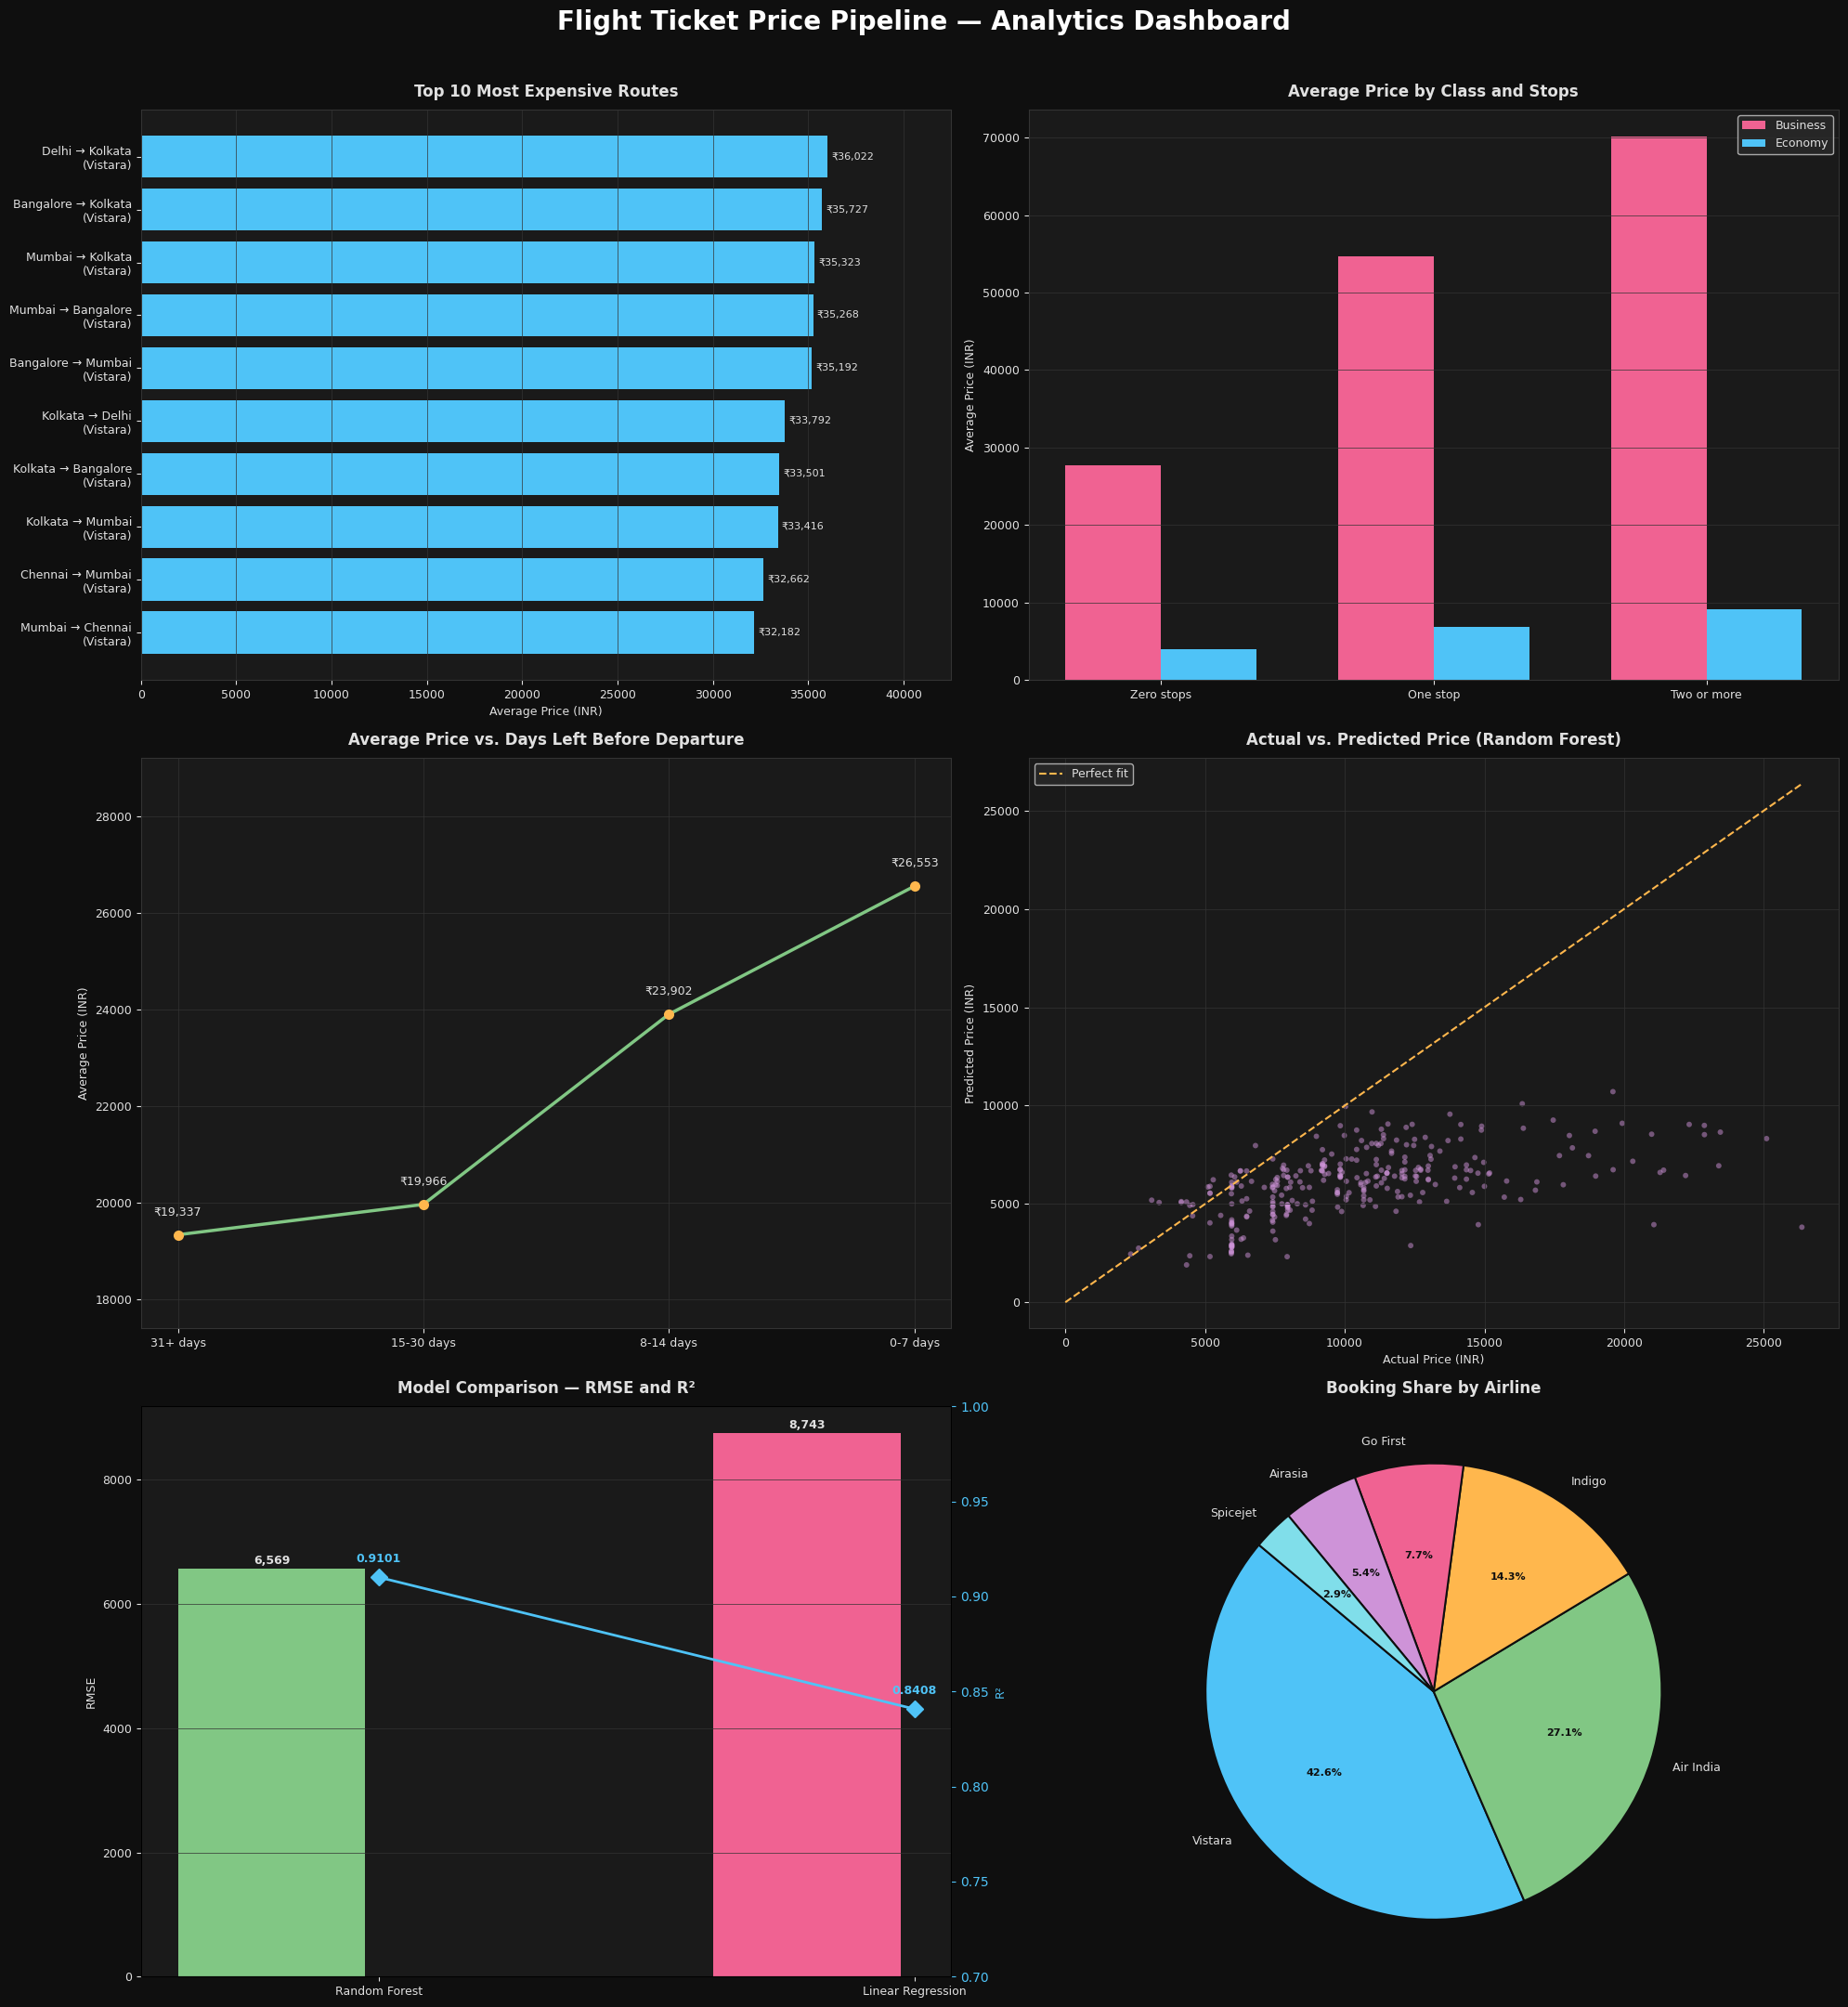

Dashboard saved to Google Drive.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Load data ────────────────────────────────────────────────
df_route   = spark.read.parquet(f"{GOLD}/avg_price_by_route").toPandas()
df_class   = spark.read.parquet(f"{GOLD}/avg_price_by_class").toPandas()
df_days    = spark.read.parquet(f"{GOLD}/avg_price_by_days_left").toPandas()
df_preds   = preds_rf.select(
    "source_city", "destination_city", "airline",
    "class", "days_left", "price", "prediction"
).limit(300).toPandas()
df_preds["prediction"] = df_preds["prediction"].round(2)

# ── Top 10 routes ─────────────────────────────────────────────
top10 = df_route.nlargest(10, "avg_price").copy()
top10["route"] = top10["source_city"].str.title() + " → " + \
                 top10["destination_city"].str.title() + "\n(" + \
                 top10["airline"].str.replace("_", " ").str.title() + ")"

# ── Figure layout ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#0f0f0f")
plt.suptitle("Flight Ticket Price Pipeline — Analytics Dashboard",
             fontsize=20, fontweight="bold", color="white", y=0.98)

ACCENT  = ["#4fc3f7","#81c784","#ffb74d","#f06292","#ce93d8","#80deea"]
BGAX    = "#1a1a1a"
TXTCOL  = "#e0e0e0"
GRIDCOL = "#333333"

def style_ax(ax, title):
    ax.set_facecolor(BGAX)
    ax.tick_params(colors=TXTCOL, labelsize=9)
    ax.set_title(title, color=TXTCOL, fontsize=12, fontweight="bold", pad=10)
    ax.spines[:].set_color(GRIDCOL)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color(TXTCOL)

# ── Chart 1: Top 10 most expensive routes (horizontal bar) ───
ax1 = fig.add_subplot(3, 2, 1)
bars = ax1.barh(top10["route"], top10["avg_price"],
                color=ACCENT[0], edgecolor="none")
ax1.set_xlabel("Average Price (INR)", color=TXTCOL, fontsize=9)
ax1.invert_yaxis()
for bar in bars:
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"₹{bar.get_width():,.0f}", va="center",
             color=TXTCOL, fontsize=8)
ax1.set_xlim(0, top10["avg_price"].max() * 1.18)
ax1.grid(axis="x", color=GRIDCOL, linewidth=0.5)
style_ax(ax1, "Top 10 Most Expensive Routes")

# ── Chart 2: Price by class and stops (grouped bar) ──────────
ax2 = fig.add_subplot(3, 2, 2)
df_class_pivot = df_class.pivot(index="stops", columns="class", values="avg_price")
stops_order = ["zero", "one", "two_or_more"]
df_class_pivot = df_class_pivot.reindex(stops_order)
x = np.arange(len(df_class_pivot))
w = 0.35
ax2.bar(x - w/2, df_class_pivot["business"], w,
        label="Business", color=ACCENT[3], edgecolor="none")
ax2.bar(x + w/2, df_class_pivot["economy"], w,
        label="Economy",  color=ACCENT[0], edgecolor="none")
ax2.set_xticks(x)
ax2.set_xticklabels(["Zero stops", "One stop", "Two or more"], color=TXTCOL)
ax2.set_ylabel("Average Price (INR)", color=TXTCOL, fontsize=9)
ax2.legend(facecolor="#2a2a2a", labelcolor=TXTCOL, fontsize=9)
ax2.grid(axis="y", color=GRIDCOL, linewidth=0.5)
style_ax(ax2, "Average Price by Class and Stops")

# ── Chart 3: Price by days left (line chart) ─────────────────
ax3 = fig.add_subplot(3, 2, 3)
bucket_order = ["31+ days", "15-30 days", "8-14 days", "0-7 days"]
df_days_sorted = df_days.set_index("days_left_bucket").reindex(bucket_order).reset_index()
ax3.plot(df_days_sorted["days_left_bucket"], df_days_sorted["avg_price"],
         color=ACCENT[1], linewidth=2.5, marker="o", markersize=8,
         markerfacecolor=ACCENT[2], markeredgewidth=0)
for i, row in df_days_sorted.iterrows():
    ax3.text(i, row["avg_price"] + 400, f"₹{row['avg_price']:,.0f}",
             ha="center", color=TXTCOL, fontsize=9)
ax3.set_ylabel("Average Price (INR)", color=TXTCOL, fontsize=9)
ax3.set_ylim(df_days_sorted["avg_price"].min() * 0.9,
             df_days_sorted["avg_price"].max() * 1.1)
ax3.grid(color=GRIDCOL, linewidth=0.5)
style_ax(ax3, "Average Price vs. Days Left Before Departure")

# ── Chart 4: Actual vs Predicted scatter ─────────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.scatter(df_preds["price"], df_preds["prediction"],
            color=ACCENT[4], alpha=0.5, s=18, edgecolors="none")
max_val = max(df_preds["price"].max(), df_preds["prediction"].max())
ax4.plot([0, max_val], [0, max_val],
         color=ACCENT[2], linewidth=1.5, linestyle="--", label="Perfect fit")
ax4.set_xlabel("Actual Price (INR)",     color=TXTCOL, fontsize=9)
ax4.set_ylabel("Predicted Price (INR)",  color=TXTCOL, fontsize=9)
ax4.legend(facecolor="#2a2a2a", labelcolor=TXTCOL, fontsize=9)
ax4.grid(color=GRIDCOL, linewidth=0.5)
style_ax(ax4, "Actual vs. Predicted Price (Random Forest)")

# ── Chart 5: Model comparison bar ────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
models = ["Random Forest", "Linear Regression"]
rmses  = [6568.75, 8742.76]
r2s    = [0.9101,  0.8408]
x = np.arange(len(models))
bars_rmse = ax5.bar(x - 0.2, rmses, 0.35,
                    label="RMSE (lower = better)",
                    color=[ACCENT[1], ACCENT[3]], edgecolor="none")
ax5.set_ylabel("RMSE", color=TXTCOL, fontsize=9)
ax5.set_xticks(x)
ax5.set_xticklabels(models, color=TXTCOL)
for bar in bars_rmse:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f"{bar.get_height():,.0f}", ha="center",
             color=TXTCOL, fontsize=9, fontweight="bold")
ax5_r2 = ax5.twinx()
ax5_r2.plot(x, r2s, color=ACCENT[0], marker="D",
            markersize=9, linewidth=2, label="R² (higher = better)")
ax5_r2.set_ylabel("R²", color=ACCENT[0], fontsize=9)
ax5_r2.tick_params(axis="y", colors=ACCENT[0])
ax5_r2.set_ylim(0.7, 1.0)
for i, v in enumerate(r2s):
    ax5_r2.text(i, v + 0.008, f"{v:.4f}", ha="center",
                color=ACCENT[0], fontsize=9, fontweight="bold")
ax5.grid(axis="y", color=GRIDCOL, linewidth=0.5)
style_ax(ax5, "Model Comparison — RMSE and R²")

# ── Chart 6: Bookings by airline (pie) ───────────────────────
ax6 = fig.add_subplot(3, 2, 6)
airline_counts = df_route.groupby("airline")["total_bookings"].sum() \
                         .sort_values(ascending=False)
airline_counts.index = airline_counts.index.str.replace("_", " ").str.title()
wedges, texts, autotexts = ax6.pie(
    airline_counts,
    labels=airline_counts.index,
    autopct="%1.1f%%",
    colors=ACCENT[:len(airline_counts)],
    startangle=140,
    wedgeprops={"edgecolor": "#0f0f0f", "linewidth": 1.5}
)
for t in texts:
    t.set_color(TXTCOL)
    t.set_fontsize(9)
for at in autotexts:
    at.set_color("#0f0f0f")
    at.set_fontsize(8)
    at.set_fontweight("bold")
style_ax(ax6, "Booking Share by Airline")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/content/drive/MyDrive/flight_pipeline/dashboard.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Dashboard saved to Google Drive.")

In [ ]:
import os

EXPORT = f"{BASE}/exports"
os.makedirs(EXPORT, exist_ok=True)

# 1. Gold: avg price by route and airline
spark.read.parquet(f"{GOLD}/avg_price_by_route") \
    .toPandas() \
    .to_csv(f"{EXPORT}/gold_route.csv", index=False)

# 2. Gold: avg price by class and stops
spark.read.parquet(f"{GOLD}/avg_price_by_class") \
    .toPandas() \
    .to_csv(f"{EXPORT}/gold_class.csv", index=False)

# 3. Gold: avg price by days left
spark.read.parquet(f"{GOLD}/avg_price_by_days_left") \
    .toPandas() \
    .to_csv(f"{EXPORT}/gold_days.csv", index=False)

# 4. Curated: sample of 5000 rows for scatter plot
spark.read.parquet(f"{CURATED}/flight_bookings") \
    .filter(F.col("is_price_outlier") == False) \
    .sample(fraction=0.02, seed=42) \
    .toPandas() \
    .to_csv(f"{EXPORT}/curated_sample.csv", index=False)

# 5. Model results summary
import pandas as pd
model_results = pd.DataFrame({
    "model":  ["Random Forest", "Linear Regression"],
    "rmse":   [6568.75, 8742.76],
    "r2":     [0.9101, 0.8408]
})
model_results.to_csv(f"{EXPORT}/model_results.csv", index=False)

print("All exports saved to Google Drive.")
print(f"Folder: {EXPORT}")

All exports saved to Google Drive.
Folder: /content/drive/MyDrive/flight_pipeline/exports


In [ ]:
# Export actual vs predicted prices from the Random Forest model
preds_rf.select("source_city", "destination_city", "airline",
                "class", "stops", "days_left", "price", "prediction") \
    .withColumn("prediction", F.round(F.col("prediction"), 2)) \
    .filter(F.col("price") > 0) \
    .sample(fraction=0.05, seed=42) \
    .toPandas() \
    .to_csv(f"{EXPORT}/model_predictions.csv", index=False)

print("Predictions exported.")

Predictions exported.
